In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
df.shape

(7043, 21)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [36]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [37]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [38]:
df.dropna(inplace=True)

In [39]:
df.shape

(7032, 21)

In [40]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

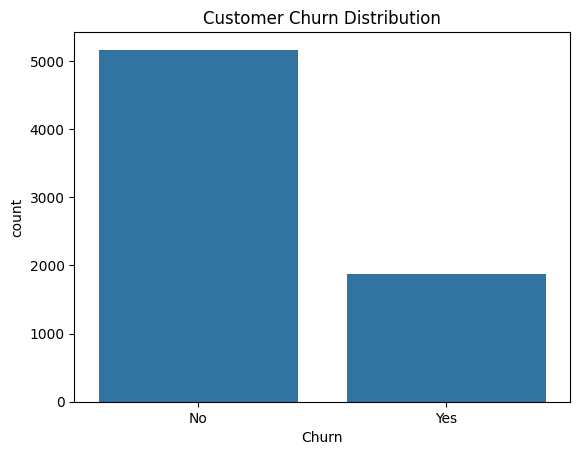

In [41]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.savefig("../visuals/churn_distribution.png")

plt.show()

In [42]:
churn_rate = df[df['Churn']=="Yes"].shape[0] / df.shape[0]

print("Churn Rate:", churn_rate)

Churn Rate: 0.26578498293515357


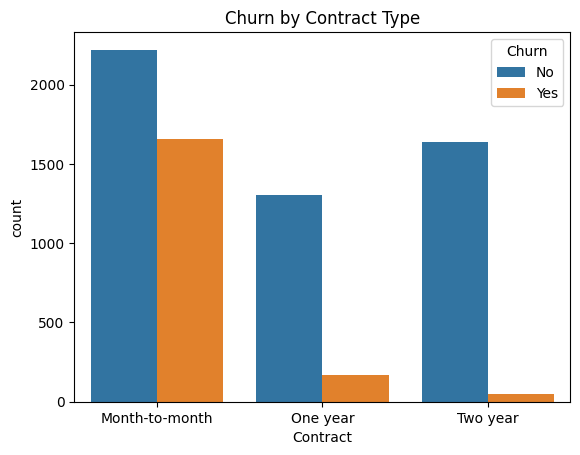

In [43]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract Type")

plt.savefig("../visuals/contract_churn.png")

plt.show()

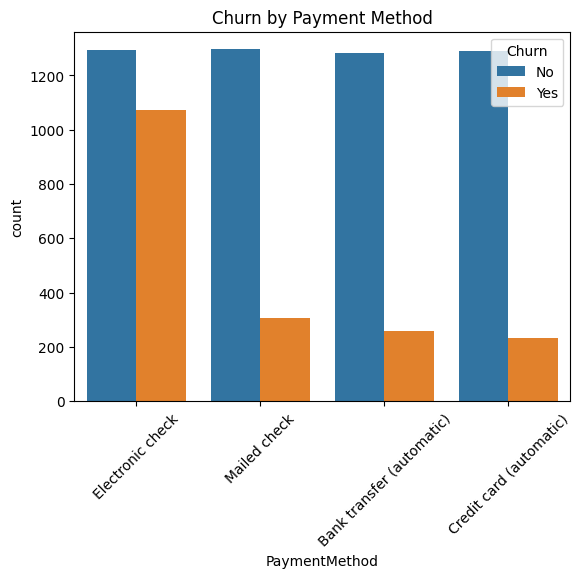

In [44]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

plt.xticks(rotation=45)

plt.title("Churn by Payment Method")

plt.savefig("../visuals/payment_churn.png")

plt.show()

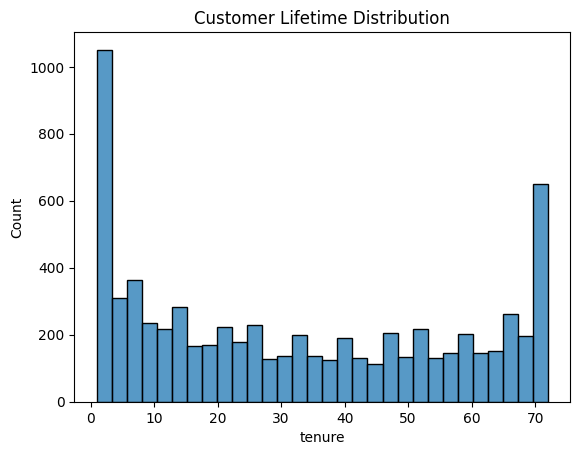

In [45]:
sns.histplot(df['tenure'], bins=30)

plt.title("Customer Lifetime Distribution")

plt.savefig("../visuals/tenure_distribution.png")

plt.show()

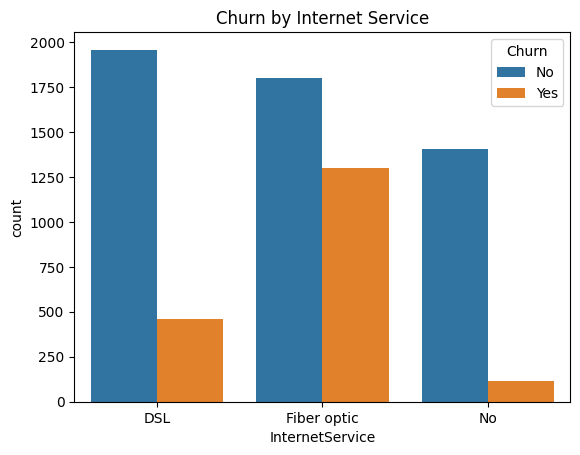

In [46]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Churn by Internet Service")

plt.savefig("../visuals/internet_churn.png")

plt.show()

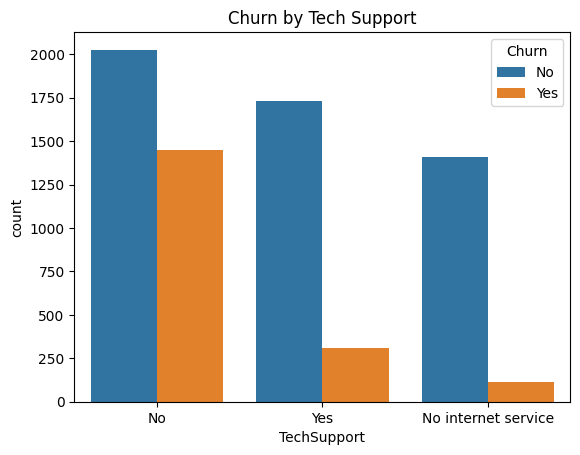

In [47]:
sns.countplot(x='TechSupport', hue='Churn', data=df)

plt.title("Churn by Tech Support")

plt.savefig("../visuals/techsupport_churn.png")

plt.show()

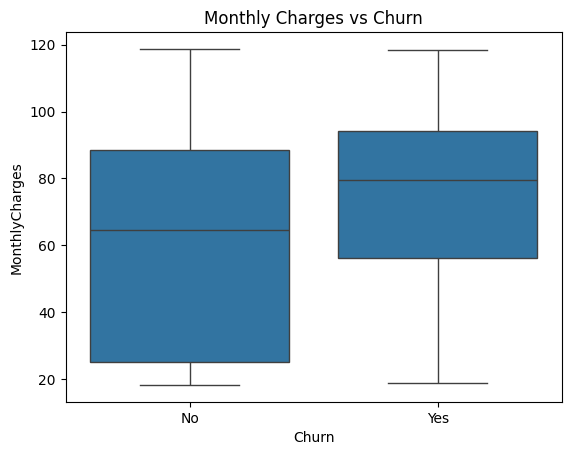

In [48]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.savefig("../visuals/monthly_charges_churn.png")

plt.show()

In [49]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72])

In [50]:
df.groupby('tenure_group')['Churn'].value_counts(normalize=True)

tenure_group  Churn
(0, 12]       No       0.523218
              Yes      0.476782
(12, 24]      No       0.712891
              Yes      0.287109
(24, 48]      No       0.796110
              Yes      0.203890
(48, 72]      No       0.904868
              Yes      0.095132
Name: proportion, dtype: float64